the flow can be trained to persue 2 task:

1) evaluate the probability density of some data 

2) sample from a simple prior and use the flow to obtain samples from a more complicated one

we now try to implement the first task: evaluating

In [49]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

Data:

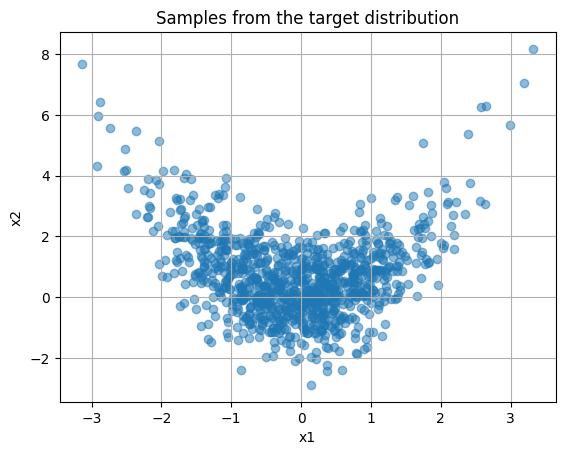

In [50]:
def sample_target(key, n):
    key, subkey = jax.random.split(key)
    z = jax.random.normal(key, (n, 2))
    x1 = z[:, 0]
    x2 = z[:, 1] + 0.7 * x1**2
    return jnp.stack([x1, x2], axis=-1), key

key = jax.random.PRNGKey(0)
x, key = sample_target(key, 1000)

plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Samples from the target distribution')
plt.grid()


the training of a function is a variational problem: we try to find the parameters that minimizie the value of functional of our function.

so first of all: 
the function needs to have parameters to be trained, and they have to be inizialize to some value at first

In [51]:
def init_params(key):
    k1, k2 = jax.random.split(key)
    return {
        "w_s": jax.random.normal(k1, (1,)),
        "b_s": jnp.zeros((1,)),
        "w_t": jax.random.normal(k2, (1,)),
        "b_t": jnp.zeros((1,)),
    }

# s(z1) = tanh(w_s * z1 + b_s)
def s(params, z1):
    return jnp.tanh(params["w_s"] * z1 + params["b_s"])

# t(z1) = w_t * z1 + b_t
def t(params, z1):
    return params["w_t"] * z1 + params["b_t"]

Affine Coupling

In [52]:
def forward(params, z):
    z1, z2 = z[:, 0], z[:, 1]

    s_value = s(params, z1)
    t_value = t(params, z1)

    x1 = z1
    x2 = z2 * jnp.exp(s_value) + t_value

    log_det = s_value

    x = jnp.stack([x1, x2], axis=-1)
    return x, log_det

def inverse(params, x):
    x1, x2 = x[:, 0], x[:, 1]

    s_value = s(params, x1)
    t_value = t(params, x1)

    z1 = x1
    z2 = (x2 - t_value) * jnp.exp(-s_value)

    log_det = -s_value

    z = jnp.stack([z1, z2], axis=-1)
    return z, log_det

In [53]:
# gaussian = exp(-0.5 * z^2) / sqrt(2 * pi)
# log gaussian = -0.5 * z^2 - 0.5 * log(2 * pi)
# we can ignore the constant term -0.5 * log(2 * pi), we don't need it for training
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=-1)

# p(x) = p(z) * |det(dz/dx)|
# log p(x) = log p(z) + log |det(dz/dx)|
def log_px(params, x):
    z, log_det = inverse(params, x)
    return log_pz(z) + log_det

to train we need a functional called loss: 
for this case we use the forward KL divergence

L = D_KL (p_target || p(x))

where p_target is the distribution of the target data and p(x) is the distribution obtain after the flow

D_KL (P || Q) = E_P (log P - log Q)

so it s the expected value of the log differeence of the two

the expected value of log p_target is costant so

L = - E_p_target [log p(x)] + const

log p(x) = log p(Z) + log |det dz / dx|

L = - E_p_target [log p(z) + log |det dz / dx] + const

we cant evaluete the p_target so if we have samples from Monte Carlo

L = - 1/N sum over data (log_x) + const

the constatn is irrelevant beacue we use the loss just to use gradient discent

In [54]:
def loss(params, x):
    return -jnp.mean(log_px(params, x))

Training

In [55]:
@jax.jit
def step(params, x, eta):
    loss_val, grads = jax.value_and_grad(loss)(params, x)
    new_params = {k: params[k] - eta * grads[k] for k in params}
    return new_params, loss_val

def train(params, x, num_steps=1000, eta=1e-3):
    losses = []
    for i in range(num_steps):
        params, loss_val = step(params, x, eta)
        losses.append(loss_val)
        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss_val:.4f}")
    return params, losses

Step 0, Loss: 4.8443
Step 100, Loss: 1.5962
Step 200, Loss: 1.5192
Step 300, Loss: 1.4649
Step 400, Loss: 1.4216
Step 500, Loss: 1.3878
Step 600, Loss: 1.3623
Step 700, Loss: 1.3440
Step 800, Loss: 1.3313
Step 900, Loss: 1.3228
Step 1000, Loss: 1.3172
Step 1100, Loss: 1.3136
Step 1200, Loss: 1.3113
Step 1300, Loss: 1.3099
Step 1400, Loss: 1.3090
Step 1500, Loss: 1.3085
Step 1600, Loss: 1.3081
Step 1700, Loss: 1.3079
Step 1800, Loss: 1.3078
Step 1900, Loss: 1.3077
Step 2000, Loss: 1.3077
Step 2100, Loss: 1.3077
Step 2200, Loss: 1.3076
Step 2300, Loss: 1.3076
Step 2400, Loss: 1.3076
Step 2500, Loss: 1.3076
Step 2600, Loss: 1.3076
Step 2700, Loss: 1.3076
Step 2800, Loss: 1.3076
Step 2900, Loss: 1.3076
Step 3000, Loss: 1.3076
Step 3100, Loss: 1.3076
Step 3200, Loss: 1.3076
Step 3300, Loss: 1.3076
Step 3400, Loss: 1.3076
Step 3500, Loss: 1.3076
Step 3600, Loss: 1.3076
Step 3700, Loss: 1.3076
Step 3800, Loss: 1.3076
Step 3900, Loss: 1.3076
Step 4000, Loss: 1.3076
Step 4100, Loss: 1.3076
Step

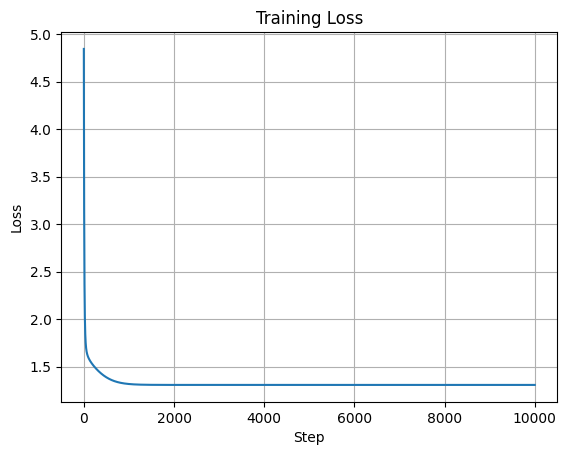

In [ ]:
n_steps = 10000
eta = 1e-2
key = jax.random.PRNGKey(0)
params = init_params(key)
params, losses = train(params, x, num_steps=n_steps, eta=eta)

plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid() 
plt.show()

Evaluating the probability of the data

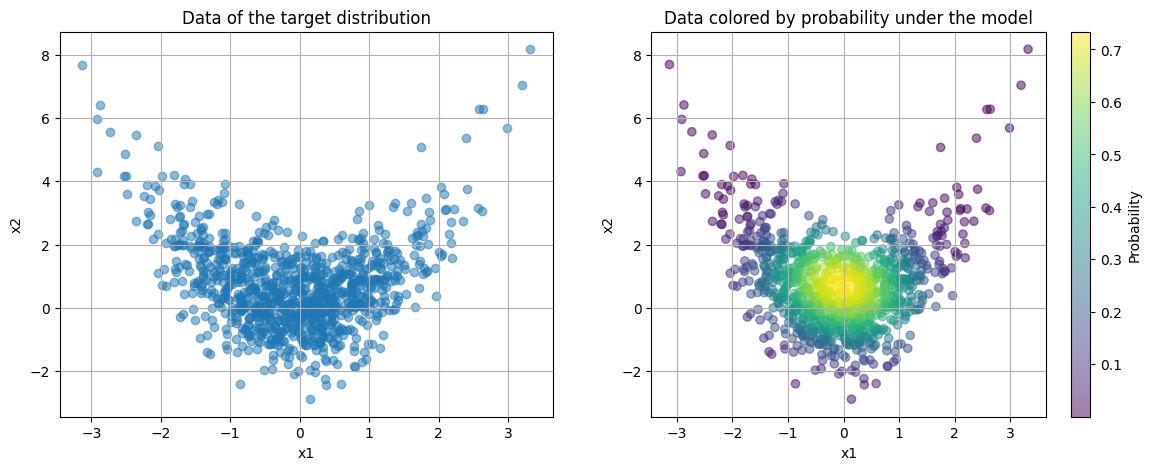

In [57]:
key = jax.random.PRNGKey(0)
x, key = sample_target(key, 1000)

# evaluate the prob of the data under the model
log_probs = log_px(params, x) # we use the parameters after training
prob = jnp.exp(log_probs)

# plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data of the target distribution')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(x[:, 0], x[:, 1], alpha=0.5, c=prob, cmap='viridis')
plt.colorbar(label='Probability')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data colored by probability under the model')
plt.grid()